# Testing The End of Everything

We have done tests to establish a System Usability Score (SUS), A/B design tests between a version of our apps with heavy use of guardrails and one completely void of such.
We will be using the Game Engagement Questionnaire standardized test for the A/B test.

## System Usability Score

In [1]:
# Import
from scipy import stats
from matplotlib import pyplot as plt
import re
import pandas as pd

In [2]:
# Load the data
dfSus = pd.read_csv("Data/SUSTest1_v6.csv")

In [3]:
# Clean the data

# Extract only the numeric response (e.g., "4 (Agree)" → 4)
def extract_numeric(response):
    match = re.match(r"(\d)", str(response))
    return int(match.group(1)) if match else None

# Columns corresponding to each SUS statement
sus_columns = [
    "STATEMENT 1: “I think that I would like to use this system frequently.”",
    "STATEMENT 2: “I found the system unnecessarily complex.”",
    "STATEMENT 3: “I thought the system was easy to use.”",
    "STATEMENT 4: “I think that I would need the support of a technical person to use this system.”",
    "STATEMENT 5: “I found the various functions in this system were well integrated.”",
    "STATEMENT 6: “I thought there was too much inconsistency in this system.”",
    "STATEMENT 7: “I would imagine that most people would learn to use this system very quickly.”",
    "STATEMENT 8: “I found the system very cumbersome to use.”",
    "STATEMENT 9: “I felt very confident using the system.”",
    "STATEMENT 10: ”I needed to learn a lot of things before I could get going with this system.”"
]

# Apply extraction to the SUS columns
sus_numeric = dfSus[sus_columns].applymap(extract_numeric)

In [4]:
# Compute adjusted scores
adjusted_scores = sus_numeric.copy()
for i in range(10):
    if (i + 1) % 2 == 1:  # Odd-numbered (positive) questions
        adjusted_scores.iloc[:, i] = sus_numeric.iloc[:, i] - 1
    else:  # Even-numbered (negative) questions
        adjusted_scores.iloc[:, i] = 5 - sus_numeric.iloc[:, i]

# Sum and compute final SUS score
dfSus["SUS Score"] = adjusted_scores.sum(axis=1) * 2.5

In [5]:
# Print the results
print(dfSus[["SUS Score"]])
dfSus["SUS Score"].describe()

    SUS Score
0        75.0
1        92.5
2        72.5
3        92.5
4        70.0
5        72.5
6        75.0
7        75.0
8        85.0
9        75.0
10       77.5
11       75.0
12       72.5
13       82.5


count    14.000000
mean     78.035714
std       7.283977
min      70.000000
25%      73.125000
50%      75.000000
75%      81.250000
max      92.500000
Name: SUS Score, dtype: float64

((array([-1.66151682, -1.18948235, -0.88997893, -0.65463235, -0.45108016,
         -0.2648058 , -0.08735875,  0.08735875,  0.2648058 ,  0.45108016,
          0.65463235,  0.88997893,  1.18948235,  1.66151682]),
  array([70. , 72.5, 72.5, 72.5, 75. , 75. , 75. , 75. , 75. , 77.5, 82.5,
         85. , 92.5, 92.5])),
 (7.043135052086345, 78.03571428571429, 0.9036769585322584))

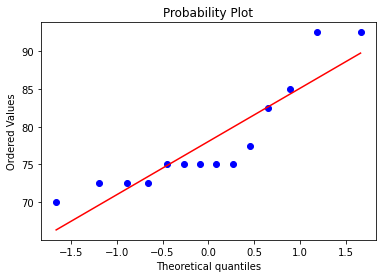

In [6]:
# Plot the results
stats.probplot(dfSus["SUS Score"], plot=plt)

In [7]:
# CI
mean = dfSus["SUS Score"].mean()
sem = stats.sem(dfSus["SUS Score"])
ci = stats.t.interval(0.95, len(dfSus["SUS Score"]) - 1, loc=mean, scale=sem)
print(f"95% CI: {ci}")

95% CI: (73.83007126602777, 82.24135730540081)


In [8]:
# Perform a one-sample t-test
t_stat, p_value = stats.ttest_1samp(dfSus["SUS Score"], popmean=67)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 5.6688623197251875
p-value: 7.682928876878458e-05


## Game Engagement Questionnaire

In [9]:
# Load the data
dfAb = pd.read_csv("Data/ABTest_v1.csv")

# Check the data
dfAb

,Name,ID,Respondent,Submission time,Test,Daily phone,Ending,Playtime in minutes,A01 I lose track of time,A02 Things seem to happen automatically,...,B01 I could easily follow the sequence of events in the game's story.,B02 The sequence of events in the game made logical sense to me.,B03 The game's objectives were clear to me throughout the gameplay.,B04 I felt like my actions affected the outcome of the game.,B05 I understood the motivation/meaning behind the main contacts messages.,B06 I had no unanswered questions about the story after completing the game,B07 I felt that the story reached a complete ending.,B08 All major plot points were resolved by the end of the game.,B09 I was left with a clear understanding of the story's outcome.,B10 The ending of the game felt appropriate for the story told.
0,1,P2N-4,Anonymous,"May 7, 2025 11:31 AM",Linear,1 iPhone,2 Reset,16,3 Yes,3 Yes,...,5,6,5,7,4,2,3,3,3,5
1,2,P2N-5,Anonymous,"May 7, 2025 12:03 PM",Linear,1 iPhone,3 Backup,15,2 Maybe,3 Yes,...,5,5,5,4,4,1,4,3,3,5
2,3,P2N-6,Anonymous,"May 7, 2025 12:54 PM",Linear,2 Android,3 Backup,19,3 Yes,2 Maybe,...,5,4,4,6,3,3,3,4,4,6
3,4,P2N-7,Anonymous,"May 7, 2025 1:16 PM",Linear,2 Android,2 Reset,8,2 Maybe,1 No,...,5,5,3,3,5,1,2,3,2,3
4,5,P2N-8,Anonymous,"May 7, 2025 1:42 PM",Linear,2 Android,2 Reset,12,3 Yes,3 Yes,...,5,5,6,4,3,3,4,2,3,3
5,6,P2N-9,Anonymous,"May 7, 2025 2:04 PM",Linear,2 Android,2 Reset,10,2 Maybe,3 Yes,...,3,3,3,4,3,1,1,1,1,1
6,7,P2N-10,Anonymous,"May 9, 2025 12:18 PM",Open,2 Android,3 Backup,9,1 No,1 No,...,5,5,5,5,3,3,4,3,3,3
7,8,P2N-11,Anonymous,"May 9, 2025 12:35 PM",Open,1 iPhone,1 Aborted,3,3 Yes,1 No,...,3,5,5,3,4,3,4,2,5,2
8,9,P2N-12,Anonymous,"May 9, 2025 12:50 PM",Open,2 Android,1 Aborted,4,2 Maybe,3 Yes,...,4,4,2,2,2,3,4,4,2,3
9,10,P2N-13,Anonymous,"May 9, 2025 1:10 PM",Open,1 iPhone,3 Backup,10,3 Yes,1 No,...,6,7,4,5,6,2,6,5,5,7
